## Ejercicio 5 - Reconstrucción en condiciones ideales

La idea central de este ejercicio es realizar un **experimento controlado**: conocemos de antemano la imagen correcta, simulamos las mediciones de un tomógrafo y después comprobamos si es posible recuperar esa imagen utilizando solamente esas mediciones.

Hacemos el proceso inverso: suponemos que no conocemos el fantoma e intentamos reconstruirlo utilizando solamente:

- La matriz de proyección $A_k$, que describe los rayos utilizados.
- El vector $b_k$, que contiene las mediciones producidas por esos rayos.

La imagen reconstruida se representa mediante $\widehat{x}_k$. Como conocemos la imagen original, podemos comparar:

$$
\widehat{x}_k
\quad\text{con}\quad
x_{\text{fantoma}}.
$$

Esto nos permite determinar si las mediciones contienen información suficiente para recuperar correctamente la imagen. Es parecido a esconder una respuesta conocida para comprobar si un método consigue encontrarla.

In [1]:
import numpy as np

from funciones import (N, X_fantoma, xfantoma, mascara_rayo, matriz_proyeccion,)

In [2]:
# las direcciones:
D2 = [(1,0), (0,1)]
D4 = D2 + [(1,1), (1,-1)]
D7 = D4 + [(2,1), (1,2), (3,1)]

# las matrices:
A2, rayos2 = matriz_proyeccion(8, D2)
A4, rayos4 = matriz_proyeccion(8, D4)
A7, rayos7 = matriz_proyeccion(8, D7)

### a) Mediciones ideales y reconstrucción

Para cada matriz de proyección generamos las mediciones ideales:

$$
b_k=A_k.x_{\text{fantoma}}
$$

Luego utilizamos `np.linalg.lstsq` para encontrar una reconstrucción $\widehat{x}_k$ que reproduzca esas mediciones.

``np.linalg.lstsq`` devuelve:
- resultado_2[0] → reconstrucción
- resultado_2[1] → residuos calculados por lstsq
- resultado_2[2] → rango de A2
- resultado_2[3] → valores singulares de A2

In [3]:
# Generar las mediciones ideales
b2 = A2 @ xfantoma
b4 = A4 @ xfantoma
b7 = A7 @ xfantoma

# Resolver cada sistema
resultado_2 = np.linalg.lstsq(A2, b2, rcond=None)
resultado_4 = np.linalg.lstsq(A4, b4, rcond=None)
resultado_7 = np.linalg.lstsq(A7, b7, rcond=None)

# Extraer la reconstrucción de cada resultado
x_reconstruida_2 = resultado_2[0]
x_reconstruida_4 = resultado_4[0]
x_reconstruida_7 = resultado_7[0]

Cada reconstrucción obtenida es un vector de 64 componentes, correspondiente a los 64 píxeles del fantoma.

La diferencia entre los tres casos está en la cantidad de información independiente que aporta cada matriz.

Si el rango de $A_k$ es menor que 64, el sistema no determina una solución única.

Esto significa que distintas imágenes pueden producir exactamente las mismas mediciones. En esos casos, `np.linalg.lstsq` selecciona, entre todas las soluciones posibles, la de menor norma. Por eso, reproducir correctamente las mediciones no garantiza haber recuperado el fantoma original.

Antes de analizar los resultados, esperamos que $A_2$ y $A_4$, cuyos rangos son menores que 64, puedan reproducir las mediciones sin recuperar exactamente el fantoma. En cambio, como $A_7$ tiene rango columna completo, debería determinar una solución única.


### b) Residuo y error relativo

Para evaluar cada reconstrucción calculamos dos medidas.

El residuo:

$$
r_k=b_k-A_k\widehat{x}_k
$$

Compara las mediciones originales con las producidas por la reconstrucción.

El error relativo:

$$
\frac{\|\widehat{x}_k-x_{\text{fantoma}}\|}
{\|x_{\text{fantoma}}\|}
$$

Compara directamente la reconstrucción con la imagen original

Por eso, un residuo cercano a cero indica que la reconstrucción reproduce correctamente las mediciones, pero no garantiza que sea igual a la imagen original. En cambio, un error relativo cercano a cero sí indica que ambas imágenes son prácticamente iguales.

In [4]:
import pandas as pd

# Inciso b)

# Calculamos los residuos
r2 = b2 - A2 @ x_reconstruida_2
r4 = b4 - A4 @ x_reconstruida_4
r7 = b7 - A7 @ x_reconstruida_7

# Calculamos las normas de los residuos
norma_residuo_2 = np.linalg.norm(r2)
norma_residuo_4 = np.linalg.norm(r4)
norma_residuo_7 = np.linalg.norm(r7)

# Norma del fantoma, utilizada en los tres errores relativos
norma_fantoma = np.linalg.norm(xfantoma)

# Calculamos los errores relativos
error_relativo_2 = (np.linalg.norm(x_reconstruida_2 - xfantoma)/ norma_fantoma)
error_relativo_4 = (np.linalg.norm(x_reconstruida_4 - xfantoma)/ norma_fantoma)
error_relativo_7 = (np.linalg.norm(x_reconstruida_7 - xfantoma)/ norma_fantoma)

# Calculamos los rangos
rango_2 = np.linalg.matrix_rank(A2)
rango_4 = np.linalg.matrix_rank(A4)
rango_7 = np.linalg.matrix_rank(A7)

# Creamos la tabla con pandas
tabla_resultados = pd.DataFrame({
    "Matriz": ["A2", "A4", "A7"],
    "Rango": [rango_2, rango_4, rango_7],
    "Norma del residuo": [
        norma_residuo_2,
        norma_residuo_4,
        norma_residuo_7
    ],
    "Error relativo": [
        error_relativo_2,
        error_relativo_4,
        error_relativo_7
    ]
})
tabla_resultados.style.format({
    "Rango": "{:d}",
    "Norma del residuo": "{:.6e}",
    "Error relativo": "{:.6f}"
})

,Matriz,Rango,Norma del residuo,Error relativo
0,A2,15,3.278919e-15,0.468927
1,A4,39,2.530363e-14,0.136461
2,A7,64,1.131330e-14,0.000000


#### Interpretación de la tabla
En los tres casos, la norma del residuo es prácticamente cero. Esto significa que las reconstrucciones reproducen correctamente las mediciones, aunque no necesariamente coincidan con el fantoma original.

La imagen tiene 64 píxeles desconocidos y el rango indica cuánta información independiente aportan las mediciones. Las matrices $A_2$ y $A_4$ tienen rangos 15 y 39, respectivamente, por lo que no permiten determinar los 64 píxeles de manera única. En estos casos, distintas imágenes pueden generar las mismas mediciones y `np.linalg.lstsq` selecciona la solución de menor norma.

Al utilizar más direcciones de proyección, el rango aumenta y la reconstrucción mejora. La matriz $A_7$ tiene rango 64, por lo que la solución es única y coincide con el fantoma original. Esto explica por qué su error relativo es prácticamente cero.

### c) Comparación visual de las reconstrucciones

Para comparar los resultados, volvemos a convertir cada vector reconstruido en una matriz de $8 \times 8$. Para cada matriz de proyección mostramos la imagen original, la reconstrucción obtenida y la diferencia entre ambas.

Usamos la misma escala de grises para la imagen original y las reconstrucciones.

La diferencia se calcula píxel por píxel restando:

$$
\text{diferencia}
=
\text{reconstrucción}
-
\text{imagen original}.
$$

En el gráfico de diferencias, el rojo indica que la reconstrucción asignó un valor mayor que el original, el azul indica que asignó un valor menor y el blanco indica que los valores son iguales o muy parecidos.

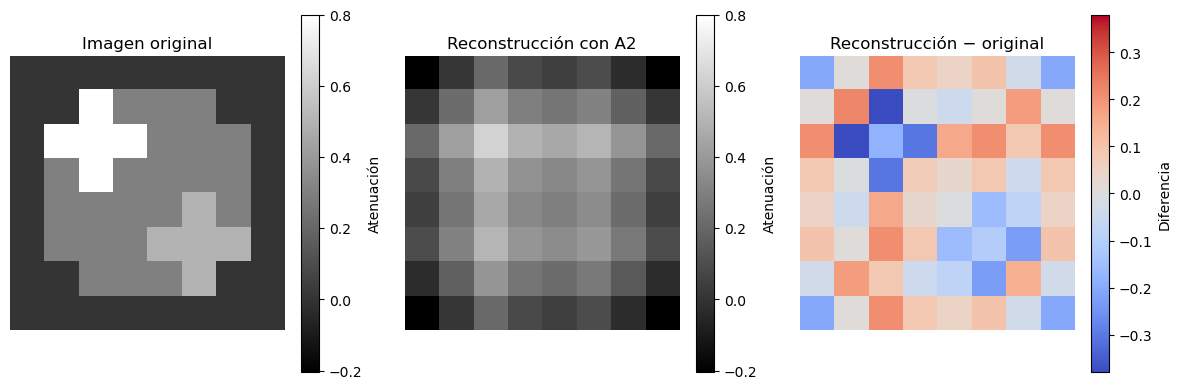

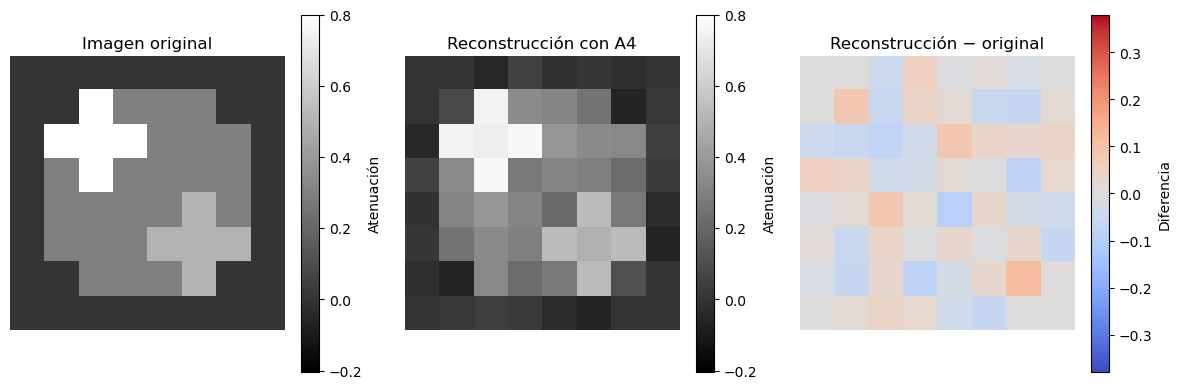

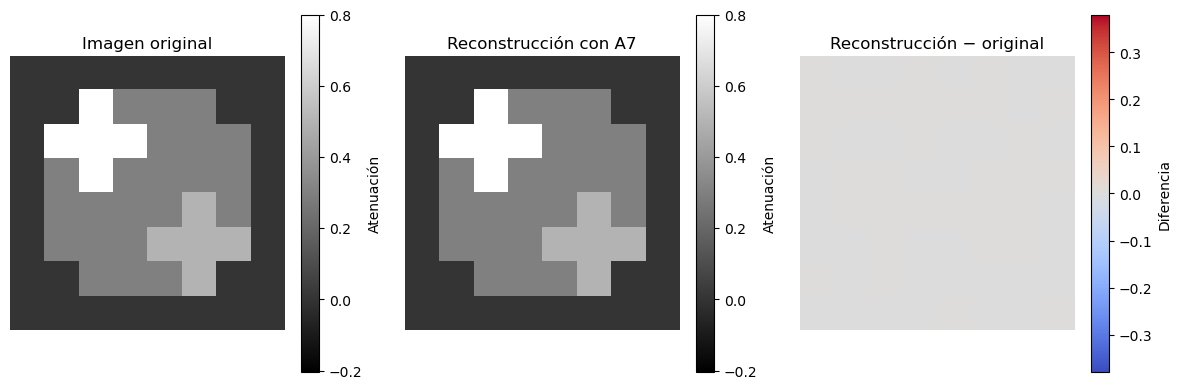

In [5]:
import matplotlib.pyplot as plt

# Convertir los vectores reconstruidos en matrices de 8×8
X_reconstruida_2 = x_reconstruida_2.reshape(8, 8)
X_reconstruida_4 = x_reconstruida_4.reshape(8, 8)
X_reconstruida_7 = x_reconstruida_7.reshape(8, 8)

reconstrucciones = {
    "A2": X_reconstruida_2,
    "A4": X_reconstruida_4,
    "A7": X_reconstruida_7
}

# Usar la misma escala de grises para la imagen original
# y para todas las reconstrucciones
vmin = min(
    X_fantoma.min(),
    X_reconstruida_2.min(),
    X_reconstruida_4.min(),
    X_reconstruida_7.min()
)

vmax = max(
    X_fantoma.max(),
    X_reconstruida_2.max(),
    X_reconstruida_4.max(),
    X_reconstruida_7.max()
)

# Calcular una escala común para los tres mapas de diferencias
limite_diferencias = max(
    np.max(np.abs(X_reconstruida_2 - X_fantoma)),
    np.max(np.abs(X_reconstruida_4 - X_fantoma)),
    np.max(np.abs(X_reconstruida_7 - X_fantoma))
)

for nombre, X_reconstruida in reconstrucciones.items():

    # Diferencia píxel por píxel
    diferencia = X_reconstruida - X_fantoma

    plt.figure(figsize=(12, 4))

    # Imagen original
    plt.subplot(1, 3, 1)
    plt.imshow(
        X_fantoma,
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )
    plt.title("Imagen original")
    plt.colorbar(label="Atenuación")
    plt.axis("off")

    # Imagen reconstruida
    plt.subplot(1, 3, 2)
    plt.imshow(
        X_reconstruida,
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )
    plt.title(f"Reconstrucción con {nombre}")
    plt.colorbar(label="Atenuación")
    plt.axis("off")

    # Diferencia entre la reconstrucción y la imagen original
    plt.subplot(1, 3, 3)
    plt.imshow(
        diferencia,
        cmap="coolwarm",
        vmin=-limite_diferencias,
        vmax=limite_diferencias
    )
    plt.title("Reconstrucción − original")
    plt.colorbar(label="Diferencia")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

En los gráficos se observa que la reconstrucción mejora a medida que agregamos direcciones de proyección.

Con $A_2$, la reconstrucción es bastante borrosa y presenta diferencias importantes respecto del fantoma. Con $A_4$, la forma de la imagen se reconoce mejor y las diferencias son menores. Finalmente, con $A_7$, la reconstrucción coincide prácticamente con la imagen original.

Aunque las tres reconstrucciones tienen un residuo cercano a cero, solamente la obtenida con $A_7$ recupera correctamente el fantoma. Esto ocurre porque el residuo sólo indica si la reconstrucción reproduce las mediciones, pero no si es igual a la imagen original.

Cuando una matriz tiene rango menor que 64, su espacio nulo contiene vectores distintos de cero. Si $z$ pertenece al espacio nulo de $A_k$, entonces:

$$
A_k z = 0
$$

y, por lo tanto,

$$
A_k(\widehat{x}_k+z)
=
A_k\widehat{x}_k+A_kz
=
b_k.
$$

Esto significa que podemos modificar una reconstrucción sumándole $z$ sin cambiar sus mediciones. Por eso, con $A_2$ y $A_4$ pueden existir distintas imágenes que tengan residuo cero.

En cambio, $A_7$ tiene rango 64 y su espacio nulo sólo contiene al vector cero. En este caso no existe esa ambigüedad, la solución es única y se recupera el fantoma original.